
**Support Virtual Machine**



Accuracy: 0.8


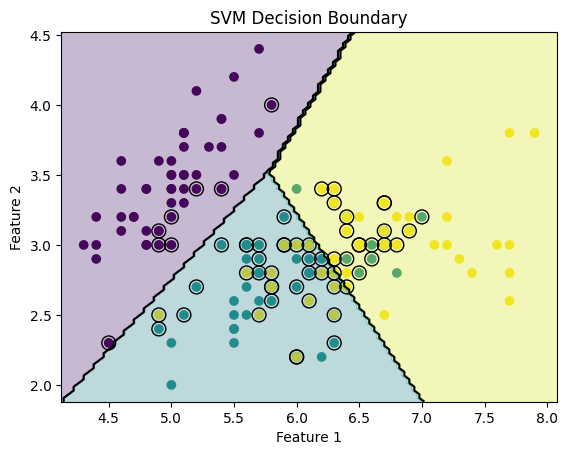

In [6]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np # Added numpy import

# Load Iris dataset
iris = datasets.load_iris()
X = iris.data[:, :2]  # Using only the first two features for easy visualization
y = iris.target

# Split data into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create and train the SVM model
model = SVC(kernel='linear')  # You can also try 'rbf' or 'poly'
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Plotting decision boundary (only works well for 2 features)
def plot_svm(model, X, y):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Create grid to evaluate model (Increased resolution from 30 to 100)
    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    # Use model.predict for multi-class decision regions
    Z = model.predict(xy).reshape(XX.shape)

    # Plot decision regions using contourf
    plt.contourf(XX, YY, Z, alpha=0.3, cmap='viridis') # Changed to contourf
    # Plot decision boundary lines (optional)
    plt.contour(XX, YY, Z, colors='k', levels=np.arange(len(np.unique(y))) + 0.5, linestyles='-')

    # Plot support vectors
    plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100,
                linewidth=1, facecolors='none', edgecolors='k')
    plt.title("SVM Decision Boundary")
    plt.xlabel("Feature 1") # Added axis labels
    plt.ylabel("Feature 2")
    plt.show()
plot_svm(model, X, y)